In [1]:
!pip install -q keras
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib
from keras.models import *
from keras.layers import *
from keras.optimizers import *
from keras.callbacks import ModelCheckpoint, LearningRateScheduler
from keras import backend as K
import torch
from PIL import Image
from torch.utils.data import Dataset

import torch.nn.functional as F
from torchvision import datasets
from torchvision import transforms
from IPython.display import display, HTML
from IPython.display import Image as Im



In [2]:
!pip install segmentation-models-pytorch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.4 MB/s eta 0:00:00


In [3]:
import segmentation_models_pytorch as smp

In [5]:
import kagglehub

path = kagglehub.dataset_download(
    "insaff/massachusetts-roads-dataset"
)


# Point directly to the flat training folders
base_train_path = os.path.join(path, "road_segmentation_ideal", "training")
image_folder = os.path.join(base_train_path, "input")
mask_folder = os.path.join(base_train_path, "output")


100%|██████████| 4.72G/4.72G [00:52<00:00, 96.3MB/s]

Extracting files...


In [7]:
import os
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
for root, dirs, files in os.walk(path):
    print(root, "→", len(files), "files")

/root/.cache/kagglehub/datasets/insaff/massachusetts-roads-dataset/versions/1 → 0 files
/root/.cache/kagglehub/datasets/insaff/massachusetts-roads-dataset/versions/1/road_segmentation_ideal → 0 files
/root/.cache/kagglehub/datasets/insaff/massachusetts-roads-dataset/versions/1/road_segmentation_ideal/testing → 0 files
/root/.cache/kagglehub/datasets/insaff/massachusetts-roads-dataset/versions/1/road_segmentation_ideal/testing/output → 13 files
/root/.cache/kagglehub/datasets/insaff/massachusetts-roads-dataset/versions/1/road_segmentation_ideal/testing/input → 13 files
/root/.cache/kagglehub/datasets/insaff/massachusetts-roads-dataset/versions/1/road_segmentation_ideal/training → 0 files
/root/.cache/kagglehub/datasets/insaff/massachusetts-roads-dataset/versions/1/road_segmentation_ideal/training/output → 804 files
/root/.cache/kagglehub/datasets/insaff/massachusetts-roads-dataset/versions/1/road_segmentation_ideal/training/input → 1105 files


In [10]:
use_cuda

True

In [8]:

import random
random.random()
IMAGE_SIZE=256


In [9]:
import torch

def make_sparse_mask(mask, num_points_per_class=5):
    sparse_mask = torch.full_like(mask, fill_value=-1)

    for class_id in [0, 1]:
        coords = (mask == class_id).nonzero()

        if len(coords) > 0:
            k = min(len(coords), num_points_per_class)
            rand_indices = torch.randperm(len(coords))[:k]
            chosen_coords = coords[rand_indices]

            for r, c in chosen_coords:
                sparse_mask[r, c] = class_id

    return sparse_mask

In [11]:
class AerialDataset(Dataset):
    def __init__(self, image_folder, mask_folder, split="train", num_points=5):
        self.image_folder = image_folder
        self.mask_folder = mask_folder
        self.split = split
        self.num_points = num_points

        # 1. Match shared files
        input_files = set(os.listdir(image_folder))
        output_files = set(os.listdir(mask_folder))
        common_files = sorted(list(input_files.intersection(output_files)))

        # 2. Slice index as an integer
        train_samples = int(0.8 * len(common_files))

        # 3. Assign files based on split
        if self.split == "train":
            self.images = common_files[:train_samples]
            self.masks = common_files[:train_samples]
        else:  # val split gets the remaining 20%
            self.images = common_files[train_samples:]
            self.masks = common_files[train_samples:]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        filename = self.images[idx]
        image_path = os.path.join(self.image_folder, filename)
        mask_path = os.path.join(self.mask_folder, filename)

        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        image = transforms.Resize((IMAGE_SIZE, IMAGE_SIZE))(image)
        mask = transforms.Resize(
            (IMAGE_SIZE, IMAGE_SIZE),
            interpolation=transforms.InterpolationMode.NEAREST
        )(mask)

        image = transforms.ToTensor()(image)
        dense_mask = (torch.tensor(list(mask.getdata())).reshape(IMAGE_SIZE, IMAGE_SIZE) > 0).long()

        # Sparsify only for training; keep dense for validation
        if self.split == "train":
            target_mask = make_sparse_mask(dense_mask, num_points_per_class=self.num_points)
        else:
            target_mask = dense_mask

        return image, target_mask

Dataset size: 643
Image shape: torch.Size([3, 256, 256])
Mask shape: torch.Size([256, 256])
Image dtype: torch.float32
Mask dtype: torch.int64
Unique mask values: tensor([-1,  0,  1])


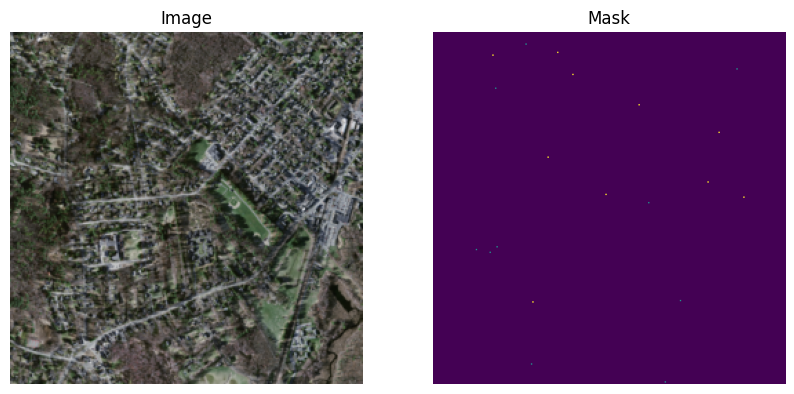

In [53]:
train_dataset = AerialDataset(
    image_folder,
    mask_folder,num_points=10
)
val_dataset=AerialDataset(
    image_folder,mask_folder,split="val"
)

print("Dataset size:", len(train_dataset))

# Get one sample
image, mask = train_dataset.__getitem__(10)

print("Image shape:", image.shape)
print("Mask shape:", mask.shape)

print("Image dtype:", image.dtype)
print("Mask dtype:", mask.dtype)

print("Unique mask values:", torch.unique(mask))


# Display
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image.permute(1, 2, 0))
plt.title("Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask)
plt.title("Mask")
plt.axis("off")

plt.show()



In [54]:
#DATA LOADING

from torch.utils.data import DataLoader
train_dataloader=DataLoader(train_dataset,batch_size=8,shuffle=True,num_workers=2,pin_memory=torch.cuda.is_available())
val_dataloader=DataLoader(val_dataset,batch_size=8,shuffle=False,num_workers=2,pin_memory=torch.cuda.is_available())

In [36]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [45]:
model=smp.Unet(
    encoder_name='resnet34',
    encoder_weights='imagenet',
    in_channels=3,classes=2
).to(device)

In [55]:
import torch.nn as nn
from tqdm import tqdm

optimizer=torch.optim.AdamW(model.parameters(),lr=1e-4,weight_decay=1e-2)
loss_method=nn.CrossEntropyLoss(ignore_index=-1)
epochs=10



In [56]:
for i in range(epochs):
    # ==========================
    # --- TRAINING PHASE ---
    # ==========================
    model.train()
    running_train_loss = 0.0

    train_bar = tqdm(train_dataloader, desc=f"Epoch {i+1}/{epochs} [Train]")
    for images, targets in train_bar:
        images = images.to(device)
        targets = targets.to(device)

        # 1. Reset gradients
        optimizer.zero_grad()

        # 2. Forward pass
        output = model(images)

        # 3. Compute loss (ignores -1)
        loss = loss_method(output, targets)

        # 4. Backward pass & weight update
        loss.backward()
        optimizer.step()

        # 5. Accumulate loss for the whole epoch
        running_train_loss += loss.item()
        train_bar.set_postfix(loss=f"{loss.item():.4f}")

    # ==========================
    # --- VALIDATION PHASE ---
    # ==========================
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        val_bar = tqdm(val_dataloader, desc=f"Epoch {i+1}/{epochs} [Val]")
        for images, targets in val_bar:
            images = images.to(device)
            targets = targets.to(device)

            outputs = model(images)
            loss = loss_method(outputs, targets)

            running_val_loss += loss.item()
            val_bar.set_postfix(val_loss=f"{loss.item():.4f}")

    # Summary per epoch
    train_epoch_loss = running_train_loss / len(train_dataloader)
    val_epoch_loss = running_val_loss / len(val_dataloader)

    print(
        f"Epoch {i+1:02d} | "
        f"Train Loss: {train_epoch_loss:.4f} | "
        f"Val Loss: {val_epoch_loss:.4f}"
    )

Epoch 1/10 [Val]: 100%|██████████| 21/21 [00:14<00:00,  1.47it/s, val_loss=0.3988]


Epoch 01 | Train Loss: 0.5208 | Val Loss: 0.5099


Epoch 2/10 [Val]: 100%|██████████| 21/21 [00:14<00:00,  1.47it/s, val_loss=0.3924]


Epoch 02 | Train Loss: 0.5064 | Val Loss: 0.5598


Epoch 3/10 [Val]: 100%|██████████| 21/21 [00:14<00:00,  1.48it/s, val_loss=0.3473]


...

Epoch 08 | Train Loss: 0.4548 | Val Loss: 0.5173


Epoch 9/10 [Val]: 100%|██████████| 21/21 [00:14<00:00,  1.46it/s, val_loss=0.5013]


Epoch 09 | Train Loss: 0.4469 | Val Loss: 0.5219


Epoch 10/10 [Val]: 100%|██████████| 21/21 [00:16<00:00,  1.25it/s, val_loss=0.4224]

Epoch 10 | Train Loss: 0.4486 | Val Loss: 0.5290


In [18]:
 import os

# Physical/logical count detected by OS
print("Total OS Cores:", os.cpu_count())

# Cores actually granted to your specific Python process
if hasattr(os, "sched_getaffinity"):
    print("Available Cores:", len(os.sched_getaffinity(0)))

Total OS Cores: 2
Available Cores: 2


Final Validation Mean Road IoU: 0.1423


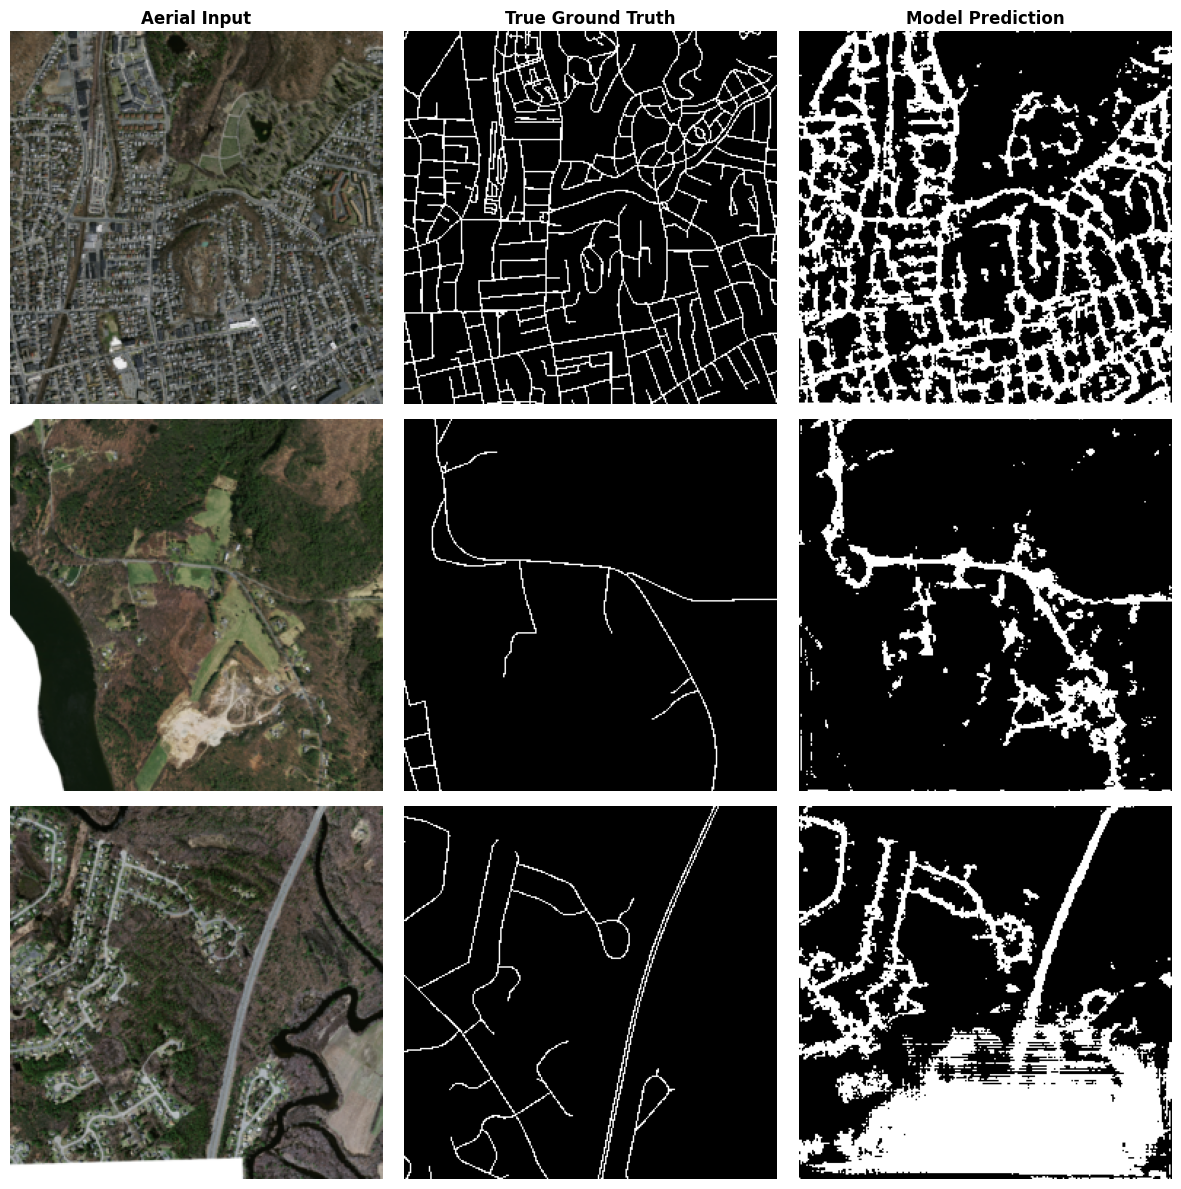

In [57]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 1. Metric function
def compute_iou(preds, targets, class_id=1, smooth=1e-6):
    pred_mask = (preds == class_id)
    true_mask = (targets == class_id)

    intersection = (pred_mask & true_mask).float().sum()
    union = (pred_mask | true_mask).float().sum()

    return ((intersection + smooth) / (union + smooth)).item()

# 2. Evaluate on full validation set
model.eval()
total_iou = 0.0

with torch.no_grad():
    for images, targets in val_dataloader:
        images = images.to(device, non_blocking=use_cuda)
        targets = targets.to(device, non_blocking=use_cuda)

        with torch.amp.autocast(device_type="cuda" if use_cuda else "cpu", enabled=use_cuda):
            outputs = model(images)

        preds = torch.argmax(outputs, dim=1)
        total_iou += compute_iou(preds, targets, class_id=1)

mean_val_iou = total_iou / len(val_dataloader)
print(f"Final Validation Mean Road IoU: {mean_val_iou:.4f}")

# 3. Visual qualitative check (Side-by-side plot)
val_iter = iter(val_dataloader)
images, targets = next(val_iter)

with torch.no_grad():
    images_dev = images.to(device, non_blocking=use_cuda)
    with torch.amp.autocast(device_type="cuda" if use_cuda else "cpu", enabled=use_cuda):
        outputs = model(images_dev)
    preds = torch.argmax(outputs, dim=1).cpu().numpy()

images = images.permute(0, 2, 3, 1).numpy()
targets = targets.numpy()

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
titles = ["Aerial Input", "True Ground Truth", "Model Prediction"]

for i in range(3):
    axes[i, 0].imshow(np.clip(images[i], 0, 1))
    axes[i, 1].imshow(targets[i], cmap="gray")
    axes[i, 2].imshow(preds[i], cmap="gray")

    for j in range(3):
        axes[i, j].axis("off")
        if i == 0:
            axes[i, j].set_title(titles[j], fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

In [58]:
torch.save(model.state_dict(), "unet_resnet34_pts10.pth")

In [59]:
fig.savefig("road_segmentation_comparison.png", dpi=300, bbox_inches="tight")
print("Visual comparison saved to road_segmentation_comparison.png")

Visual comparison saved to road_segmentation_comparison.png


5 Points IoU: 0.1192
10 Points IoU: 0.1423
50 Points IoU: 0.1192


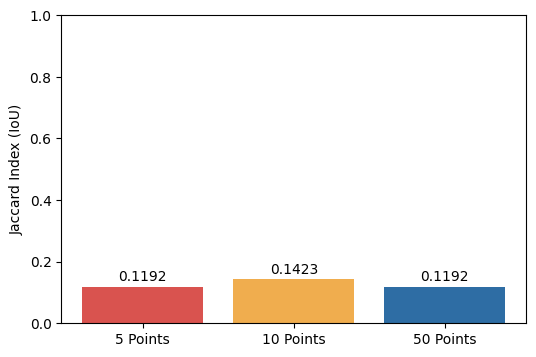

In [61]:
import torch
import numpy as np
import matplotlib.pyplot as plt

checkpoints = {
    "5 Points": "unet_resnet34_pts20.pth",
    "10 Points": "unet_resnet34_pts10.pth",
    "50 Points": "unet_resnet34_pts50.pth"
}

def get_iou(preds, targets):
    p = (preds == 1)
    t = (targets == 1)
    return (((p & t).float().sum() + 1e-6) / ((p | t).float().sum() + 1e-6)).item()

ious = []

for name, path in checkpoints.items():
    model.load_state_dict(torch.load(path, map_location=device))
    model.eval()

    score = 0.0
    with torch.no_grad():
        for images, targets in val_dataloader:
            images = images.to(device)
            targets = targets.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            score += get_iou(preds, targets)

    mean_score = score / len(val_dataloader)
    ious.append(mean_score)
    print(f"{name} IoU: {mean_score:.4f}")

labels = list(checkpoints.keys())

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, ious, color=["#d9534f", "#f0ad4e", "#2e6da4"])
plt.ylabel("Jaccard Index (IoU)")
plt.ylim(0, 1)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, y + 0.02, f"{y:.4f}", ha="center")

plt.savefig("checkpoint_ious.png")
plt.show()